In [1]:
import sys
sys.path.append("..")
from src.ingest.itf import parse_itf, to_numeric, parse_itf_to_parts

In [2]:
parsed_sample, stats = parse_itf("../data/itf_slice100k.txt")
print(len(parsed_sample), "rows parsed")
print(stats)

98300 rows parsed
{'parsed': 98300, 'skipped': 1410}


In [3]:
print(parsed_sample.columns.tolist())

['desig', 'date_str', 'ra_str', 'dec_str', 'fmt', 'obscode']


In [4]:
%%time
#this cell is for testing the speed of my string --> numerical conversion functions
converted = to_numeric(parsed_sample) #creates a new variable that stores the modified rows

CPU times: user 16.4 s, sys: 227 ms, total: 16.6 s
Wall time: 18.1 s


In [5]:
print(parsed_sample.memory_usage(deep=True).sum() / 1e6, "MB for 100k rows")

10.335501 MB for 100k rows


In [6]:
print(parsed_sample.columns.tolist())

['desig', 'date_str', 'ra_str', 'dec_str', 'fmt', 'obscode']


In [7]:
%%time
KEEP = ["desig", "ra_str", "dec_str", "date_str", "obscode", "fmt"]
1

CPU times: user 16 μs, sys: 1 μs, total: 17 μs
Wall time: 19.6 μs


1

In [8]:
%%time
#this cell should parse the ITF, save it to an itf_numeric file (which was deleted, but is something I should later comment out)
#itf_parsed = parse_itf_to_parts("../data/itf.txt", "../data/itf_numeric", 100_000, keep=KEEP)

CPU times: user 5 μs, sys: 0 ns, total: 5 μs
Wall time: 9.54 μs


In [9]:
#%%time
#this cell will convert the parqet files generated from the full parsing of the ITF
import os, glob
import pandas as pd

src_dir = "../data/itf_numeric" #the text parts I already have
out_dir = "../data/itf_converted" #where the converted parts will go
#os.makedirs(out_dir, exist_ok=True)

KEEP = ["desig", "ra_deg", "dec_deg", "time", "obscode"] #what I want to keep once the new columns have been created

parts = sorted(glob.glob(f"{src_dir}/part_*.parquet"))
#print(len(parts), "parts to convert")

#for i, p in enumerate(parts):
#    df = to_numeric(pd.read_parquet(p))
#    df[KEEP].to_parquet(f"{out_dir}/part_{i:03d}.parquet")
#    if i % 10 == 0:
#        print(f"part {i:03d} done")
#    del df

#print("all parts converted")


In [10]:
%%time
#this cell will stitch all of the new files in itf_converted together.
converted = sorted(glob.glob(f"{out_dir}/part_*.parquet"))

full = pd.concat([pd.read_parquet(p) for p in converted], ignore_index=True)

print(f"{len(full):,} rows")
#full.to_parquet("../data/itf_numeric_full.parquet")

9,054,785 rows
CPU times: user 1.25 s, sys: 935 ms, total: 2.18 s
Wall time: 16.7 s


In [3]:
#this is simply a setup cell that gives me variables and libraries I need
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd()
while not (ROOT / "data").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
DATA = ROOT / "data"
print("repo root:", ROOT)

repo root: /workspaces/Project-INTERLOPER


In [12]:
%%time
#This cell will verify that every group of rows sharing a designation is really one short burst of looks at a single object, all within a single night, instead of different objects, or the same object over time

df = pd.read_parquet(DATA / "itf_numeric_full.parquet") #This line loads the full table off the disk, into memory. DATA is the data/ folder path. / joins the path pieces. this should take up no more than 1gb of my available 5
g = df.groupby("desig") #sorts all 9 million rows into piles, with each unique designation getting its own pile, which should give me about 2.5 million piles.

t = pd.DataFrame({ #starts building a new table, with one row per pile, instead of per observation. each entry below becomes a column, with the name on the left and the values on the right
"n_obs": g.size(), #column one. has the number of observations each designation pile has. shows whether 283 is an outlier or is normal.
"t_start": g["time"].min(), #this line and the one below are columsn two and three. within each pile, they're the earliest timestamp and the latest.
"t_end": g["time"].max(),
}) #closes "dictionary"

t["span_hours"] = (t["t_end"] - t["t_start"]).dt.total_seconds() / 3600 #this is the actual test. subtacting the timestamps gives a duration. ".dt.total_seconds()" then converts this special type into a plain number of seconds. Then, it's all divided by 3600, to convert it into hours. because I assigned it to t["span_hours"], i'm giving it all a new column

print(t["n_obs"].describe()) #describe prints a summary of a column, specifically the number of values, the average, the smallest, largest, and quarter marks. here, it will tell me the typical observation count per desig
print(t["span_hours"].describe()) #same summary, but instead is for duration. will reveal the numbers about time between obs
print("spans over 24h:", (t["span_hours"] > 24).sum()) #this is a really important number. it prints the maount of designations that stretch for longer than a single day. different outcomes mean different things
    #A Small Count: designations are effectively tracklets, so I can just group by designation, compute rates, and then move on
    #A Large Count: designations are objects followed across many nights. I need to start by splitting each into per-night chunks, then compute rates on the chunks.


count    2.547914e+06
mean     3.553803e+00
std      3.125248e+00
min      1.000000e+00
25%      3.000000e+00
50%      3.000000e+00
75%      4.000000e+00
max      2.830000e+02
Name: n_obs, dtype: float64
count    2.547914e+06
mean     2.170125e+01
std      1.350034e+03
min      0.000000e+00
25%      3.997680e-01
50%      6.477600e-01
75%      9.002400e-01
max      1.297545e+06
Name: span_hours, dtype: float64
spans over 24h: 15048
CPU times: user 2.08 s, sys: 1.36 s, total: 3.45 s
Wall time: 16 s


In [ ]:
%%time
#this cell is to build the tracklet table WITH RATES
import numpy as np #needed for cos, square roots, and math applied to entire columns

df = pd.read_parquet( #this loads the table, but only the listed four columns. this stops obscode from ever being read, which has caused kernel crashes before
    DATA / "itf_numeric_full.parquet",
    columns = ["desig", "ra_deg", "dec_deg", "time"]
)

df = df.sort_values(["desig", "time"], kind="stable") # sorts by designation, then by time within each designation. "first" and "last" equal "earliest" and "latest". kind = "stable" means rows that tie keep their relative order, making the result constent, aiding reproductability
g = df.groupby("desig", sort=False) #piles the rows by designation
t = g.agg( #.agg creates several summaries per pile, in one pass. each line creates a column named that, by taking that column and applying the given opperation to each pile. this would mean that ra_start is the ra of the earliest obesrvation in each pile, ra_end is the RA of the latest.
    n_obs = ("time", "size"),
    t_start = ("time", "first"),
    t_end = ("time", "last"),
    ra_start = ("ra_deg", "first"),
    ra_end = ("ra_deg", "last"),
    dec_start = ("dec_deg", "first"),
    dec_end = ("dec_deg", "last")
)

del df #deletes df in the memory now that the summaries are created, preventing a crash

t["span_hours"] = (t["t_end"] - t["t_start"]).dt.total_seconds() / 3600 #duration of each tracklet in hours. same method as before

#the four lines below count what is going to be thrown away. There are three reasons why a tracklet couldn't give a rate. 1. there is only one observation. 2. there is zero elapsed time. 3. spanning more than a day. Counting before cutting is very intentional, tells me how much of everything I actually excluded
n_all = len(t)
n_single = (t["n_obs"] < 2).sum()
n_zero = ((t["n_obs"] >= 2) & (t["span_hours"] <= 0)).sum()
n_long = ((t["n_obs"] >= 2) & (t["span_hours"] > 24)).sum()


t = t[(t["n_obs"] >= 2) & (t["span_hours"] > 0) & (t["span_hours"] <= 24)].copy() #keeps only the usable rows. .copy() creates an actually new table.
dra = ((t["ra_end"] - t["ra_start"] + 180) % 360) - 180 #fixes the issue caused by RA "wrapping" around. RA runs from 0 degrees to 360 degrees, and then restarts, so an object that crosses the seam looks like it jumped hundreds of degrees, when it may have only been .2 degrees. The trick used here is to add 180, and then take the remainded when divided by 360, and subtract 180. this folds any differentce into the range, -180 to +180, being the shrotest way around.
dec_mid = (t["dec_start"] + t["dec_end"]) / 2 #the declination halfway between the start and the end, used for correction. uses the midpoint instead of either end because the correction changes with latitude and the midpoint is fairer
dra_sky = dra * np.cos(np.radians(dec_mid)) #converts RA degrees into "real sky degrees". lines of ra get closet together near the poles, like longitude lines, so one degree is a full degree of the sky ONLY AT THE EQUATOR, as you go up or down, it shrinks. multiplying by cos(declination) applies the shrink.
ddec = t["dec_end"] - t["dec_start"] #north-south movement, with no needed correction
t["sep_deg"] = np.hypot(dra_sky, ddec) #combines the east-weth and north-south into one distance. nyp.hpot(a, b) is the hypotaneuse, which is valid here because the tracklets are tiny little "patches" in the sky, so small that the curvature of the earth is negligable
t["rate_dpd"] = t["sep_deg"] / (t["span_hours"] / 24) #the answer. distance divided by time. turns hours into days, so the units are degrees per day.

#the below print statements print the audit "trail", and then the rate summary. The :;\, inserts seperators by thousands, so that the 9 digit numbers are actually readable.
print(f"tracklets total:      {n_all:,}")
print(f"  dropped, 1 obs:     {n_single:,}")
print(f"  dropped, zero span: {n_zero:,}")
print(f"  dropped, over 24h:  {n_long:,}")
print(f"  kept:               {len(t):,}")
print()
print(t["rate_dpd"].describe())

#The below saves the new rate data to a new file in data
#t = t.reset_index()
#t.to_parquet(DATA / "tracklets.parquet", index=False)
#print("saved:", (DATA / "tracklets.parquet").stat().st_size / 1e6, "MB")

tracklets total:      2,547,914
  dropped, 1 obs:     1,117
  dropped, zero span: 58
  dropped, over 24h:  15,048
  kept:               2,531,691

count    2.531691e+06
mean     1.175394e+00
std      5.470720e+01
min      0.000000e+00
25%      1.684251e-01
50%      2.151275e-01
75%      2.450273e-01
max      1.033638e+04
Name: rate_dpd, dtype: float64
saved: 152.600168 MB
CPU times: user 5.69 s, sys: 2.27 s, total: 7.97 s
Wall time: 25.1 s


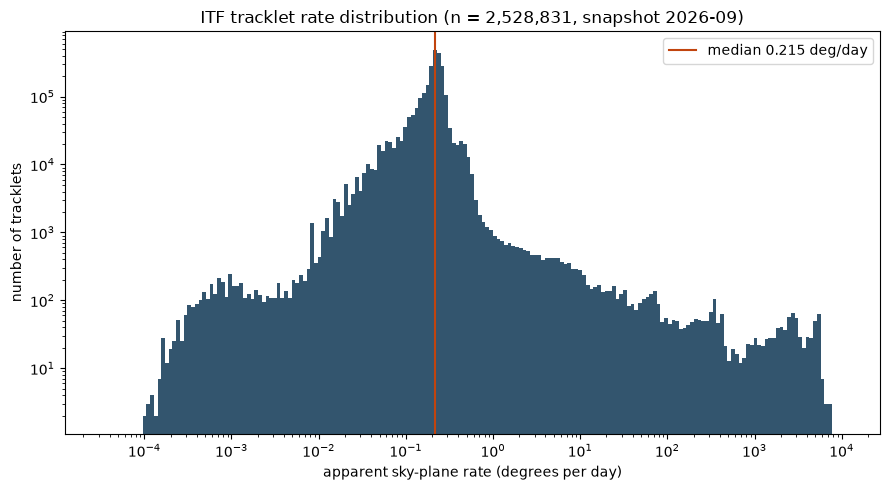

CPU times: user 2.09 s, sys: 374 ms, total: 2.46 s
Wall time: 2.76 s


In [ ]:
%%time
#this cell plots and saves the above data
import matplotlib.pyplot as plt #plotting library

t = pd.read_parquet(DATA / "tracklets.parquet") #loads the tracklet table from the saved file, instead of trusting that t is in memory (don't need to run above cell)
r = t["rate_dpd"] #pulls out just the rate column, names it r, so everything below is easier
r = r[r > 0] #keeps only rates above zero (a log axis can't show zero)

fig, ax = plt.subplots(figsize=(9,5)) #creates a blank chart. fig is the image and ax is the plotting area. 9 in wide, 5 tall.
bins = np.logspace(np.log10(r.min()), np.log10(r.max()), 200) #sets up slots rates are "sorted" into
ax.hist(r, bins=bins, color="#33556e") #draws the histogram, a bar chart where the bar height equals the num of tracklets that landed in that bin. this color is a dark blue
ax.set_xscale("log") #puts the horozintal axis on a log scale. NEEDED
ax.set_yscale("log") #same thing but for the vertical axis

ax.axvline(r.median(), color="#c1440e", lw=1.5, label=f"median {r.median():.3f} deg/day") #draws a vertical line at the median rate in orange. lw is the line width, label is the text in the legend
ax.set_xlabel("apparent sky-plane rate (degrees per day)") #labels x axis
ax.set_ylabel("number of tracklets") #labels y axis
ax.set_title(f"ITF tracklet rate distribution (n = {len(r):,}, snapshot 2026-09)") #the title. n = num tracklets in the chart. "snapshot 2026-09", is important because the iTF keeps shrinking, so which version of the archive it comes from is important information
ax.legend() #shows the legend box
fig.tight_layout() #nudges the spacing so labels dont get cut off

#fig.savefig(ROOT / "figures" / "itf_rate_distribution_v1.png", dpi=150) #saves the chart to my figures folder, 150 dpi
plt.show() #displays chart in notebook.


